# Analyse descriptive — Polémique CNC

**Phase 1 : comprendre la viralité du corpus X/Twitter.**

Le notebook répond aux 5 axes : *qui a lancé / amplifié ?*, *comment ?*, *pourquoi ça a pris ?*,
*depuis quand ?*, *à quelle vitesse ?*

### Comment l'utiliser
1. Place `data.xlsx` dans le même dossier que ce notebook.
2. Menu **Cellule → Exécuter tout** (ou `Run All`). La 1ʳᵉ cellule installe les dépendances.


In [ ]:
# --- 1. Installation des dépendances (à lancer une seule fois) ---
%pip install -q pandas numpy openpyxl matplotlib

In [1]:
# --- 2. Imports & configuration ---
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

%matplotlib inline
pd.set_option("display.max_colwidth", 60)

# Chemins (relatifs au notebook)
DATA_PATH = Path("data.xlsx")     # <-- ton fichier de corpus
OUTDIR = Path("resultats")
OUTDIR.mkdir(exist_ok=True)

# Palette
INK, ACCENT, BLUE, GREY = "#1a1a2e", "#e94560", "#3a86ff", "#6c757d"

ORIGINAL_LABEL = "ORIGINAL"
NARRATIVES = {
    "Argent public":      ["subvention", "subventionne", "argent public", "finance", "millions", "contribuable", "impot"],
    "Clivage politique":  ["gauche", "droite", "rn", "lfi", "macron", "bellamy", "marechal"],
    "Censure / liberté":  ["censure", "liberte", "art", "creation"],
    "Anti-France":        ["insultant", "anti france", "anti-france", "france", "drapeau"],
    "Élites / filiations":["fils de", "frere de", "duhamel", "saint cricq", "gavras"],
}
print("Configuration OK")

Configuration OK


## 3. Chargement & nettoyage

In [2]:
def load_dataset(path: Path) -> pd.DataFrame:
    if path.suffix.lower() in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    return pd.read_csv(path, sep="\t" if path.suffix.lower() == ".tsv" else ",")

def clean_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"].astype(str).str.replace(r"\.0$", "", regex=True), errors="coerce")
    df["Engagement Type"] = df["Engagement Type"].fillna(ORIGINAL_LABEL).replace("", ORIGINAL_LABEL)
    for c in ["Likes","Comments","Shares","Impressions","Reach","X Followers","X Following","X Posts"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)
    return df

df = clean_dataset(load_dataset(DATA_PATH))
print(f"{len(df):,} posts  |  {df.shape[1]} colonnes")
df.head(3)

35,396 posts  |  30 colonnes


,Date,Url,Domain,Sentiment,Language,Country,City Code,Author,City,Expanded URLs,...,X Reply to,X Repost of,X Posts,X Verified,Reach,Engagement Type,Hashtags,postID,postDate,message_normalizer
0,2026-05-01 21:43:00,http://twitter.com/Chaumont_Loire/statuses/2050330168393...,twitter.com,neutral,fr,France,NaN,Chaumont_Loire,NaN,https://www.cnc.fr/cinema/actualites/le-jardin-fait-son-...,...,NaN,NaN,9211,False,3434,ORIGINAL,#googlealerts,1,2026-05-01,« le jardin fait son cinema » au festival international...
1,2026-05-01 21:38:40,http://twitter.com/GuzmanStephane/statuses/2050329079019...,twitter.com,neutral,fr,France,NaN,GuzmanStephane,NaN,https://x.com/FrDesouche/status/2050142007771709749/video/1,...,NaN,http://twitter.com/destinationcine/statuses/205029484131...,348374,False,851,RETWEET,NaN,2,2026-05-01,"rt @ destinationcine le clip "" storm "" de romain gavras ..."
2,2026-05-01 21:37:39,http://twitter.com/Lancelo34643571/statuses/205032882321...,twitter.com,neutral,fr,France,NaN,Lancelo34643571,NaN,https://x.com/JPatrierLeitus/status/2049899199735451697,...,NaN,http://twitter.com/FrDesouche/statuses/2050109211221123487,126326,False,2039,RETWEET,NaN,3,2026-05-01,"rt @ frdesouche la choregraphie est formidable , mais po..."


## 4. Chiffres clés

In [3]:
d0, d1 = df["Date"].min(), df["Date"].max()
chiffres = {
    "Total posts": len(df),
    "Auteurs uniques": df["Author"].nunique(),
    "Période": f"{d0:%d/%m/%Y} → {d1:%d/%m/%Y}",
    "Durée (jours)": (d1 - d0).days,
    "Reach cumulé": int(df["Reach"].sum()),
    "Impressions cumulées": int(df["Impressions"].sum()),
    "Part de retweets (%)": round((df["Engagement Type"] == "RETWEET").mean()*100, 1),
}
pd.DataFrame(chiffres.items(), columns=["Indicateur", "Valeur"])

,Indicateur,Valeur
0,Total posts,35396
1,Auteurs uniques,10437
2,Période,19/03/2026 → 01/05/2026
3,Durée (jours),42
4,Reach cumulé,77769119
5,Impressions cumulées,52116415
6,Part de retweets (%),85.8


## 5. Comment ? — nature des messages & sentiment

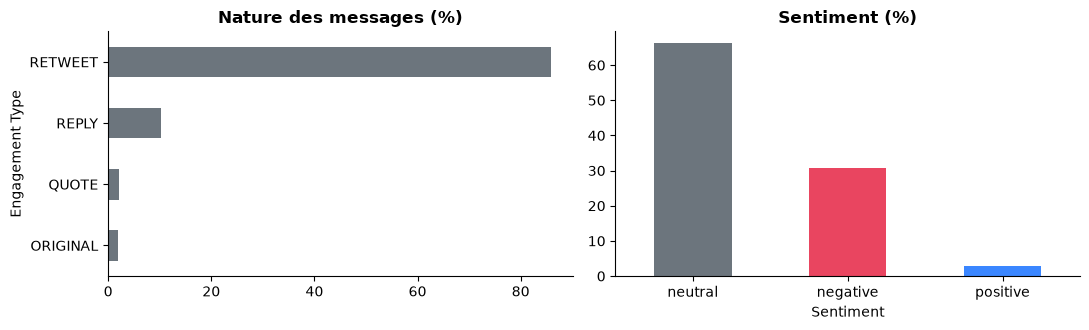

Engagement: {'RETWEET': 85.8, 'REPLY': 10.2, 'QUOTE': 2.1, 'ORIGINAL': 1.9}
Sentiment: {'neutral': 66.3, 'negative': 30.7, 'positive': 3.0}


In [4]:
eng = (df["Engagement Type"].value_counts(normalize=True)*100).round(1)
sent = (df["Sentiment"].value_counts(normalize=True)*100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
eng.reindex(["RETWEET","REPLY","QUOTE","ORIGINAL"]).plot.barh(ax=axes[0], color=GREY)
axes[0].set_title("Nature des messages (%)", fontweight="bold"); axes[0].invert_yaxis()
sent.plot.bar(ax=axes[1], color=[GREY, ACCENT, BLUE])
axes[1].set_title("Sentiment (%)", fontweight="bold"); axes[1].tick_params(axis="x", rotation=0)
for ax in axes:
    for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()
print("Engagement:", eng.to_dict()); print("Sentiment:", sent.to_dict())

## 6. Qui ? — primo-diffuseurs & amplificateurs

In [5]:
# Primo-diffuseurs : messages originaux ayant généré le plus de retweets
rt_counts = df["X Repost of"].dropna().astype(str).value_counts()
orig = df[df["Engagement Type"] == ORIGINAL_LABEL].copy()
orig["RT reçus"] = orig["Url"].astype(str).map(rt_counts).fillna(0).astype(int)
primo = orig.sort_values("RT reçus", ascending=False).head(10)[["Author","RT reçus","Reach","X Followers","X Verified","Date"]]
display(primo.reset_index(drop=True))

# Amplificateurs : comptes les plus retweetés
amp = (df[df["X Repost of"].notna()]
       .assign(cible=lambda x: x["X Repost of"].astype(str).str.extract(r"twitter\.com/([^/]+)/")[0])
       .groupby("cible").size().sort_values(ascending=False).head(10)
       .rename("Reprises").reset_index().rename(columns={"cible":"Compte"}))
display(amp)

,Author,RT reçus,Reach,X Followers,X Verified,Date
0,LeDindonFiscal,654,1044963,1988,True,2026-03-29 10:21:57
1,Crohnfighter,623,787029,46002,True,2026-04-19 09:36:27
2,LeCNC,509,2855797,90238,True,2026-03-26 14:08:46
3,GuilhemCarayon,420,579251,46401,True,2026-03-26 12:30:15
4,ojim_france,412,521605,35748,True,2026-03-26 16:53:05
5,LeDindonFiscal,348,543313,873,True,2026-03-26 14:51:22
6,JanisEnsucre,324,382561,23893,True,2026-04-06 07:39:36
7,ojim_france,305,511757,35798,True,2026-03-27 17:33:02
8,libremax_off,281,366236,16930,True,2026-03-26 23:19:21
9,CerfiaFR,243,967287,1285098,True,2026-03-26 14:55:43


,Compte,Reprises
0,SirAfuera,1852
1,LeDindonFiscal,1544
2,ojim_france,1254
3,jon_delorraine,1083
4,anatolium,1065
5,charlesvillaa,1000
6,SirenesFR,856
7,EugenieBastie,791
8,fxbellamy,771
9,Crohnfighter,623


## 7. Depuis quand & à quelle vitesse

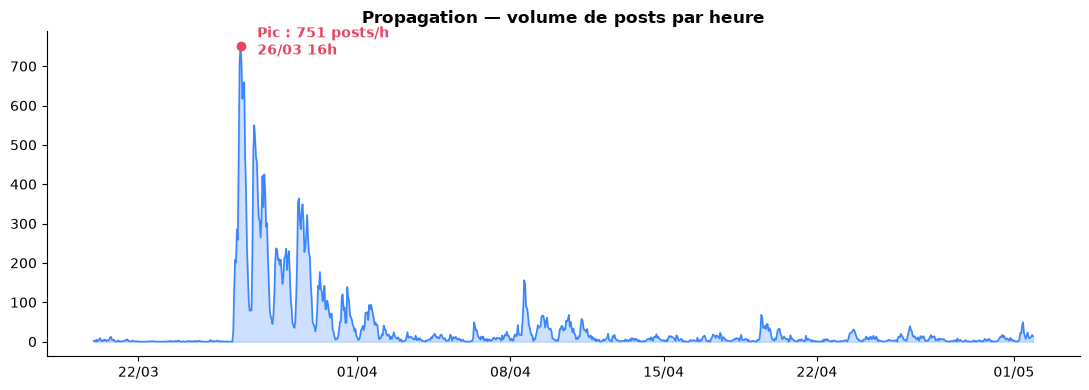

Premier post     : 19/03 23h
Pic              : 26/03 16h  (751 posts/h)
Délai début→pic  : 160.8 h
Temps doublement : 49.1 h


In [6]:
hourly = df.dropna(subset=["Date"]).set_index("Date").resample("h").size()
peak_t, peak_v = hourly.idxmax(), int(hourly.max())
delai_h = round((peak_t - df["Date"].min()).total_seconds()/3600, 1)

# Temps de doublement (régression log-linéaire sur la montée)
montee = hourly.loc[:peak_t].cumsum(); montee = montee[montee > 0]
coef = np.polyfit(np.arange(len(montee)), np.log(montee.values), 1)[0]
doubling_h = round(np.log(2)/coef, 1) if coef > 0 else None

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(hourly.index, hourly.values, color=BLUE, alpha=0.25)
ax.plot(hourly.index, hourly.values, color=BLUE, lw=1.2)
ax.scatter([peak_t], [peak_v], color=ACCENT, zorder=5)
ax.annotate(f"Pic : {peak_v} posts/h\n{peak_t:%d/%m %Hh}", (peak_t, peak_v),
            xytext=(12,-6), textcoords="offset points", color=ACCENT, fontweight="bold")
ax.set_title("Propagation — volume de posts par heure", fontweight="bold")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

print(f"Premier post     : {df['Date'].min():%d/%m %Hh}")
print(f"Pic              : {peak_t:%d/%m %Hh}  ({peak_v} posts/h)")
print(f"Délai début→pic  : {delai_h} h")
print(f"Temps doublement : {doubling_h} h")

## 8. Pourquoi ça a pris — angles narratifs

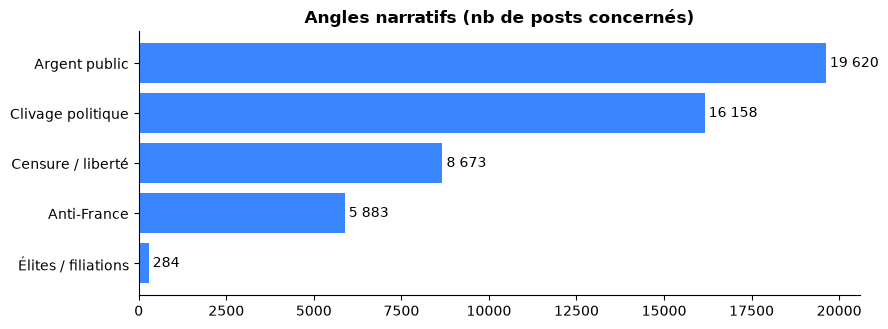

{'Élites / filiations': 284,
 'Anti-France': 5883,
 'Censure / liberté': 8673,
 'Clivage politique': 16158,
 'Argent public': 19620}

In [7]:
text = df["message_normalizer"].fillna("").astype(str)
narr = {}
for angle, kws in NARRATIVES.items():
    mask = np.zeros(len(text), dtype=bool)
    for kw in kws: mask |= text.str.contains(kw, regex=False)
    narr[angle] = int(mask.sum())
narr = dict(sorted(narr.items(), key=lambda kv: kv[1]))

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.barh(list(narr.keys()), list(narr.values()), color=BLUE)
for i, v in enumerate(narr.values()): ax.text(v, i, f" {v:,}".replace(",", " "), va="center")
ax.set_title("Angles narratifs (nb de posts concernés)", fontweight="bold")
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()
narr

## 9. Export des résultats

In [8]:
resultats = {
    "chiffres_cles": chiffres,
    "engagement_pct": eng.to_dict(),
    "sentiment_pct": sent.to_dict(),
    "primo_diffuseurs": primo.assign(Date=primo["Date"].astype(str)).to_dict("records"),
    "amplificateurs": amp.to_dict("records"),
    "vitesse": {"pic": str(peak_t), "pic_volume": peak_v, "delai_debut_pic_h": delai_h, "doublement_h": doubling_h},
    "narratifs": narr,
}
(OUTDIR / "analyse_notebook.json").write_text(json.dumps(resultats, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
hourly.rename("volume").to_csv(OUTDIR / "timeline_horaire.csv")
print("Exporté dans :", OUTDIR.resolve())

Exporté dans : D:\IASchool\25-26\datathon\Datathon\resultats
